# Phase 1 — Extract
Load the dataset into PySpark.
Tasks
Initialize Spark Session in Google Colab
Define schema explicitly
Load CSV properly
Handle malformed records
Validate null values
Print schema and sample records


In [ ]:
#install pyspark and findspark
!pip install pyspark findspark

#initialize findspark
import findspark
findspark.init()

#initialize spark session in google colab
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

#define schema explicitly - Removed as schema will be inferred and then casted

#load CSV properly
df = spark.read.csv("/content/drive/MyDrive/india_job_market_2024_2026.csv", header=True)

#Handle malformed records by type casting and checking for nulls
from pyspark.sql.functions import col, sum
from pyspark.sql.types import IntegerType, DoubleType, DateType

# Print the initial schema to inspect column names and inferred data types
print("Initial Schema:")
df.printSchema()

# Validate null values initially (after inference, before explicit casting)
print("Null counts after initial inference:")
null_counts_initial = df.select([sum(col(c).isNull().cast("integer")).alias(c) for c in df.columns])
null_counts_initial.show()

# List of columns to cast to IntegerType
int_cols = ['Openings', 'Applicants']

# List of columns to cast to DoubleType
double_cols = ['Salary_LPA', 'Company_Rating']

# Cast IntegerType columns
for col_name in int_cols:
    df = df.withColumn(col_name, col(col_name).cast(IntegerType()))

# Cast DoubleType columns
for col_name in double_cols:
    df = df.withColumn(col_name, col(col_name).cast(DoubleType()))

# Cast Date_Posted to DateType
df = df.withColumn('Date_Posted', col('Date_Posted').cast(DateType()))

# Print the updated schema to verify data types after casting
print("Schema after type casting:")
df.printSchema()

# Re-validate null values after type conversion (to find malformed records that became nulls)
print("Null counts after type casting (malformed records become nulls):")
null_counts_after_cast = df.select([sum(col(c).isNull().cast("integer")).alias(c) for c in df.columns])
null_counts_after_cast.show()

# Print sample records
print("Sample Records:")
df.show()

Initial Schema:
root
 |-- Job_ID: string (nullable = true)
 |-- Job_Title: string (nullable = true)
 |-- Company: string (nullable = true)
 |-- Company_Type: string (nullable = true)
 |-- Industry: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Location_Tier: string (nullable = true)
 |-- Experience_Level: string (nullable = true)
 |-- Job_Type: string (nullable = true)
 |-- Work_Mode: string (nullable = true)
 |-- Salary_LPA: string (nullable = true)
 |-- Skills_Required: string (nullable = true)
 |-- Education_Required: string (nullable = true)
 |-- Openings: string (nullable = true)
 |-- Applicants: string (nullable = true)
 |-- Company_Rating: string (nullable = true)
 |-- Date_Posted: string (nullable = true)

Null counts after initial inference:
+------+---------+-------+------------+--------+----+-------------+----------------+--------+---------+----------+---------------+------------------+--------+----------+--------------+-----------+
|Job_ID|Job_Title|Comp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Phase 2 — Feature Engineering and Advanced Transformation


In [ ]:
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.sql.functions import col

# Ensure salary_vector column does not exist before creating it
if "salary_vector" in df.columns:
    df = df.drop("salary_vector")

# Assemble 'Salary_LPA' into a feature vector
vector_assembler = VectorAssembler(inputCols=["Salary_LPA"], outputCol="salary_vector")
df = vector_assembler.transform(df)

# Ensure Salary_LPA_scaled column does not exist before creating it
if "Salary_LPA_scaled" in df.columns:
    df = df.drop("Salary_LPA_scaled")

# Apply StandardScaler
scaler = StandardScaler(inputCol="salary_vector", outputCol="Salary_LPA_scaled", withStd=True, withMean=False)
scaler_model = scaler.fit(df)
df = scaler_model.transform(df)
df = df.drop("salary_vector") # Drop the temporary vector column

from pyspark.sql.functions import upper, trim

categorical_cols = [
    "Company_Type",
    "Industry",
    "City",
    "Location_Tier",
    "Experience_Level",
    "Job_Type",
    "Work_Mode",
    "Education_Required"
]

for c in categorical_cols:
    df = df.withColumn(c, upper(trim(col(c))))

#Standardize categorical text columns
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import when

categorical_cols = [
    "Company_Type",
    "Industry",
    "City",
    "Location_Tier",
    "Experience_Level",
    "Job_Type",
    "Work_Mode",
    "Education_Required"
]

for col_name in categorical_cols:
    # Ensure the indexed column does not exist before creating it
    if col_name + "_indexed" in df.columns:
        df = df.drop(col_name + "_indexed")
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_indexed")
    df = indexer.fit(df).transform(df)

#Convert posting date into proper date datatype (corrected column name)
from pyspark.sql.functions import to_date
df = df.withColumn("Date_Posted", col("Date_Posted").cast("date")) # Already casted in previous cell, but reconfirming type

#CREATE Salary_Per_Applicant
df = df.withColumn(
    "Salary_Per_Applicant",
    when(
        col("Applicants") != 0,
        col("Salary_LPA") / col("Applicants")
    ).otherwise(0)
)
#CREATE Hiring_Demand_Index
df = df.withColumn(
    "Hiring_Demand_Index",
    col("Openings") / (col("Applicants") + 1)
)
#CREATE Remote_Flag
df = df.withColumn(
    "Remote_Flag",
    when(
        col("Work_Mode") == "REMOTE",
        1
    ).otherwise(0)
)
#CREATE High_Paying_Job_Flag
df = df.withColumn(
    "High_Paying_Job_Flag",
    when(
        col("Salary_LPA") >= 20,
        1
    ).otherwise(0)
)
#CREATE Skill_Count
from pyspark.sql.functions import split, size

df = df.withColumn(
    "Skill_Count",
    size(
        split(col("Skills_Required"), ",")
    )
)
#CHECK NEW FEATURES
df.select(
    "Salary_LPA",
    "Applicants",
    "Openings",
    "Work_Mode",
    "Skills_Required", # Corrected column name here
    "Salary_Per_Applicant",
    "Hiring_Demand_Index",
    "Remote_Flag",
    "High_Paying_Job_Flag",
    "Skill_Count"
).show(10, truncate=False)
#ADVANCED TRANSFORMATION — explode()
from pyspark.sql.functions import explode

skills_df = df.withColumn(
    "Skill",
    explode(
        split(col("Skills_Required"), ",") # Corrected column name here
    )
)
#CLEAN EXPLODED SKILLS
from pyspark.sql.functions import trim, upper

skills_df = skills_df.withColumn(
    "Skill",
    upper(trim(col("Skill")))
)
#CREATE SKILL FREQUENCY TABLE
skill_frequency = skills_df.groupBy("Skill") \
    .count() \
    .orderBy(col("count").desc())
#VIEW TOP SKILLS
skill_frequency.show(20)
#SAVE INTERMEDIATE CLEANED DATA
import os

folders = [
    "output/raw",
    "output/cleaned",
    "output/transformed",
    "output/analytics",
    "output/reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

df.write.mode("overwrite").parquet(
    "output/cleaned/jobs_cleaned"
)
skills_df.write.mode("overwrite").parquet(
    "output/transformed/skills_data"
)
# Display the updated schema and a sample of the transformed data
print("Schema after transformations:")
df.printSchema()

print("Sample Records after transformations:")
df.show()

+----------+----------+--------+---------+--------------------------------------------------------------+--------------------+--------------------+-----------+--------------------+-----------+
|Salary_LPA|Applicants|Openings|Work_Mode|Skills_Required                                               |Salary_Per_Applicant|Hiring_Demand_Index |Remote_Flag|High_Paying_Job_Flag|Skill_Count|
+----------+----------+--------+---------+--------------------------------------------------------------+--------------------+--------------------+-----------+--------------------+-----------+
|25.6      |110       |1       |HYBRID   |React, Next.js, HTML/CSS, TypeScript, Redux, JavaScript       |0.23272727272727273 |0.009009009009009009|0          |1                   |6          |
|84.8      |159       |2       |ON-SITE  |Publications, NLP, Deep Learning, PyTorch                     |0.5333333333333333  |0.0125              |0          |1                   |4          |
|18.0      |115       |1       |ON-

## UC1 - Hiring Demand Analytics

INDUSTRY-WISE HIRING AGGREGATION - Which industries have the highest job openings?

In [ ]:
from pyspark.sql.functions import sum, avg, count

industry_hiring = df.groupBy("Industry").agg(
    sum("Openings").alias("Total_Openings"),
    avg("Salary_LPA").alias("Average_Salary"),
    count("*").alias("Total_Jobs")
).orderBy(col("Total_Openings").desc())

industry_hiring.show(20, truncate=False)

industry_hiring.write.mode("overwrite").csv(
    "output/analytics/industry_hiring",
    header=True
)

+----------------------+--------------+------------------+----------+
|Industry              |Total_Openings|Average_Salary    |Total_Jobs|
+----------------------+--------------+------------------+----------+
|INFORMATION TECHNOLOGY|5578          |20.39553398058256 |1545      |
|FINTECH               |2145          |18.87569060773482 |543       |
|E-COMMERCE            |1967          |19.270450097847363|511       |
|BANKING & FINANCE     |1463          |20.84851485148516 |404       |
|EDTECH                |1391          |20.469077306733176|401       |
|HEALTHTECH            |1068          |17.291717791411045|326       |
|MANUFACTURING         |968           |20.695669291338593|254       |
|CONSULTING            |861           |18.473180076628356|261       |
|GOVERNMENT/PSU        |664           |19.26782178217822 |202       |
|GAMING                |546           |18.623972602739727|146       |
|MEDIA & ENTERTAINMENT |545           |18.55202702702703 |148       |
|LOGISTICS          

#### CITY-WISE APPLICANT ANALYSIS - Which cities attract the most job applicants?

In [ ]:
city_applicants = df.groupBy("City").agg(
    sum("Applicants").alias("Total_Applicants"),
    sum("Openings").alias("Total_Openings"),
    avg("Salary_LPA").alias("Average_Salary")
).orderBy(col("Total_Applicants").desc())

city_applicants.show(20, truncate=False)



+-----------+----------------+--------------+------------------+
|City       |Total_Applicants|Total_Openings|Average_Salary    |
+-----------+----------------+--------------+------------------+
|REMOTE     |579354          |7009          |19.85948795180721 |
|PUNE       |119534          |1490          |20.888679245283015|
|MUMBAI     |119060          |1366          |20.03010752688173 |
|HYDERABAD  |110788          |1322          |19.81225626740947 |
|BANGALORE  |102487          |1220          |20.474127906976754|
|DELHI      |95903           |1222          |17.799999999999997|
|CHENNAI    |94653           |1174          |20.58385093167702 |
|JAIPUR     |36236           |411           |21.093877551020405|
|LUCKNOW    |35563           |436           |18.075510204081638|
|BHUBANESWAR|32425           |390           |22.257425742574256|
|CHANDIGARH |29923           |340           |17.206593406593402|
|KOLKATA    |28082           |350           |23.777894736842097|
|INDORE     |27503       

In [ ]:
#APPLICANT-TO-OPENING RATIO
ratio_df = df.withColumn(
    "Applicant_Opening_Ratio",
    col("Applicants") / (col("Openings") + 1)
)
ratio_df.select(
    "Company",
    "Applicants",
    "Openings",
    "Applicant_Opening_Ratio"
).show(10, truncate=False)

+-----------+----------+--------+-----------------------+
|Company    |Applicants|Openings|Applicant_Opening_Ratio|
+-----------+----------+--------+-----------------------+
|Meesho     |110       |1       |55.0                   |
|Groww      |159       |2       |53.0                   |
|Amazon     |115       |1       |57.5                   |
|Leadsquared|222       |2       |74.0                   |
|Leadsquared|193       |2       |64.33333333333333      |
|Zoho       |378       |10      |34.36363636363637      |
|Fi Money   |383       |5       |63.833333333333336     |
|Zerodha    |79        |1       |39.5                   |
|NTPC       |948       |10      |86.18181818181819      |
|Infosys    |191       |2       |63.666666666666664     |
+-----------+----------+--------+-----------------------+
only showing top 10 rows


In [ ]:
#COMPANY HIRING RANKINGS
from pyspark.sql.window import Window
from pyspark.sql.functions import dense_rank, col

window_spec = Window.orderBy(
    col("Openings").desc()
)

company_ranking = df.withColumn(
    "Hiring_Rank",
    dense_rank().over(window_spec)
)
company_ranking.select(
    "Company",
    "Industry",
    "Openings",
    "Hiring_Rank"
).show(20, truncate=False)

+-------------+----------------------+--------+-----------+
|Company      |Industry              |Openings|Hiring_Rank|
+-------------+----------------------+--------+-----------+
|Wipro        |E-COMMERCE            |20      |1          |
|Byju's       |INFORMATION TECHNOLOGY|20      |1          |
|Urban Company|BANKING & FINANCE     |20      |1          |
|Darwinbox    |MANUFACTURING         |20      |1          |
|Deloitte     |INFORMATION TECHNOLOGY|20      |1          |
|Postman      |INFORMATION TECHNOLOGY|20      |1          |
|Deloitte     |FINTECH               |20      |1          |
|Capgemini    |INFORMATION TECHNOLOGY|20      |1          |
|Cisco        |MEDIA & ENTERTAINMENT |20      |1          |
|Tech Mahindra|E-COMMERCE            |20      |1          |
|Accenture    |MANUFACTURING         |20      |1          |
|HAL          |BANKING & FINANCE     |20      |1          |
|Cisco        |FINTECH               |20      |1          |
|BHEL         |INFORMATION TECHNOLOGY|20

In [ ]:
#CREATE INDUSTRY vs LOCATION TIER ANALYTICS
industry_location = df.groupBy(
    "Industry",
    "Location_Tier"
).agg(
    sum("Openings").alias("Total_Openings"),
    sum("Applicants").alias("Total_Applicants")
)
industry_location.show(20, truncate=False)

+----------------------+-------------+--------------+----------------+
|Industry              |Location_Tier|Total_Openings|Total_Applicants|
+----------------------+-------------+--------------+----------------+
|INFORMATION TECHNOLOGY|TIER 2       |1070          |88505           |
|GAMING                |TIER 2       |105           |10330           |
|GOVERNMENT/PSU        |TIER 2       |143           |11495           |
|TELECOM               |TIER 2       |4             |342             |
|E-COMMERCE            |REMOTE       |651           |51826           |
|LOGISTICS             |TIER 1       |188           |16225           |
|CONSULTING            |REMOTE       |272           |21556           |
|FINTECH               |TIER 1       |849           |66364           |
|EDTECH                |TIER 1       |521           |44148           |
|MANUFACTURING         |TIER 1       |372           |32968           |
|INFORMATION TECHNOLOGY|TIER 1       |2389          |198271          |
|EDTEC

In [ ]:
#CACHE ANALYTICAL DATAFRAMES
industry_hiring.cache()
city_applicants.cache()
company_ranking.cache()
industry_location.cache()
#CONVERT TO PANDAS FOR VISUALIZATION
industry_pd = industry_hiring.toPandas()
city_pd = city_applicants.toPandas()
company_pd = company_ranking.toPandas()
industry_location_pd = industry_location.toPandas()
heatmap_pd = industry_location.toPandas()

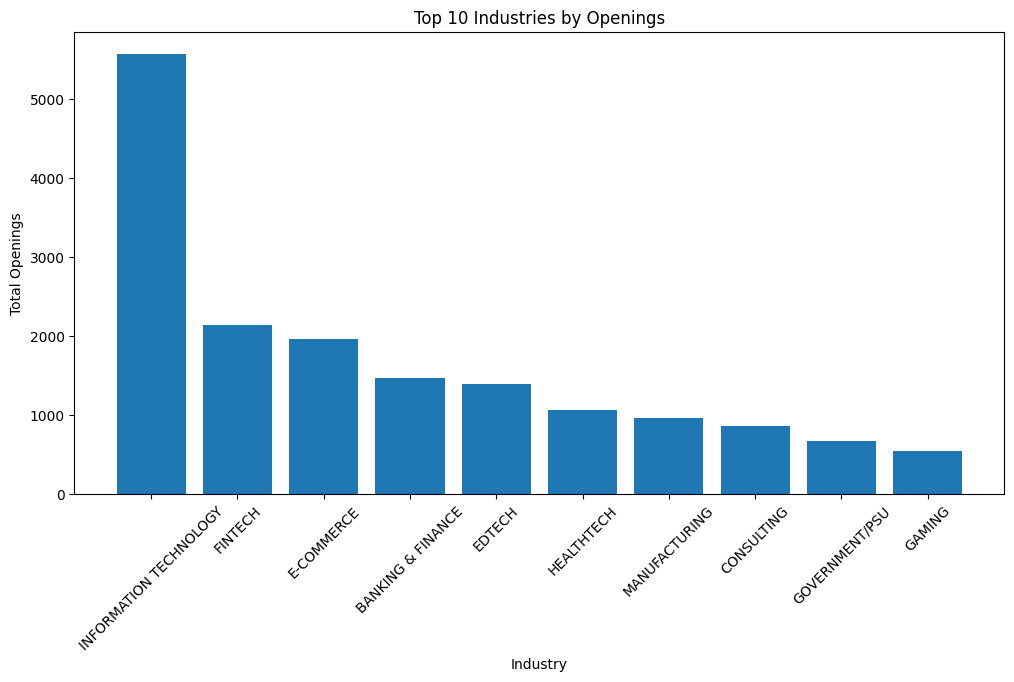

In [ ]:
#VISUALIZATION 1 - TOP 10 INDUSTRIES BY OPENINGS
import matplotlib.pyplot as plt

top10_industries = industry_pd.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_industries["Industry"],
    top10_industries["Total_Openings"]
)

plt.xticks(rotation=45)

plt.xlabel("Industry")
plt.ylabel("Total Openings")
plt.title("Top 10 Industries by Openings")

plt.show()

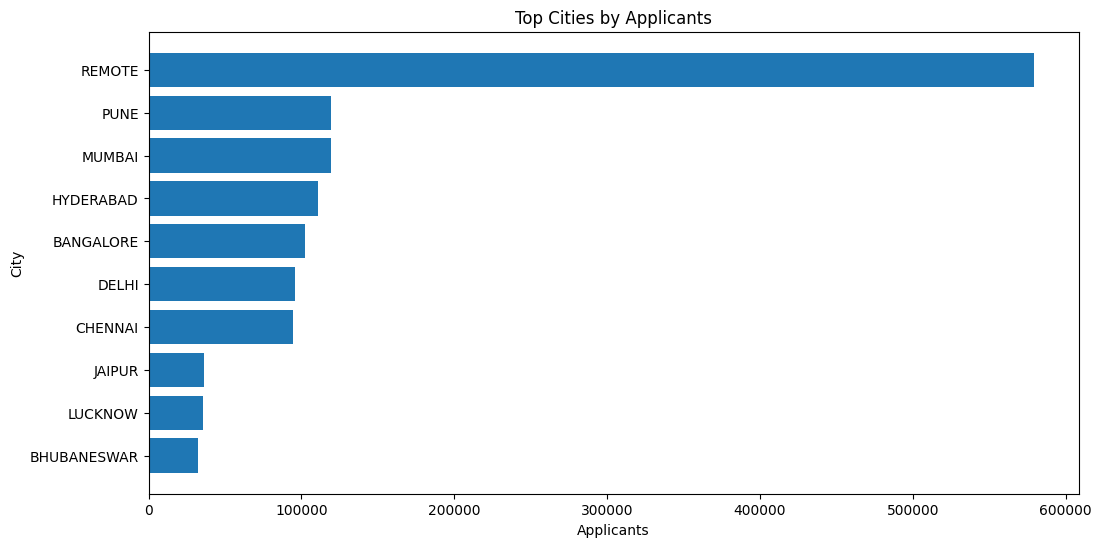

In [ ]:
#VISUALIZATION 2 - TOP CITIES BY APPLICANTS
top_cities = city_pd.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_cities["City"],
    top_cities["Total_Applicants"]
)

plt.xlabel("Applicants")
plt.ylabel("City")
plt.title("Top Cities by Applicants")

plt.gca().invert_yaxis()

plt.show()

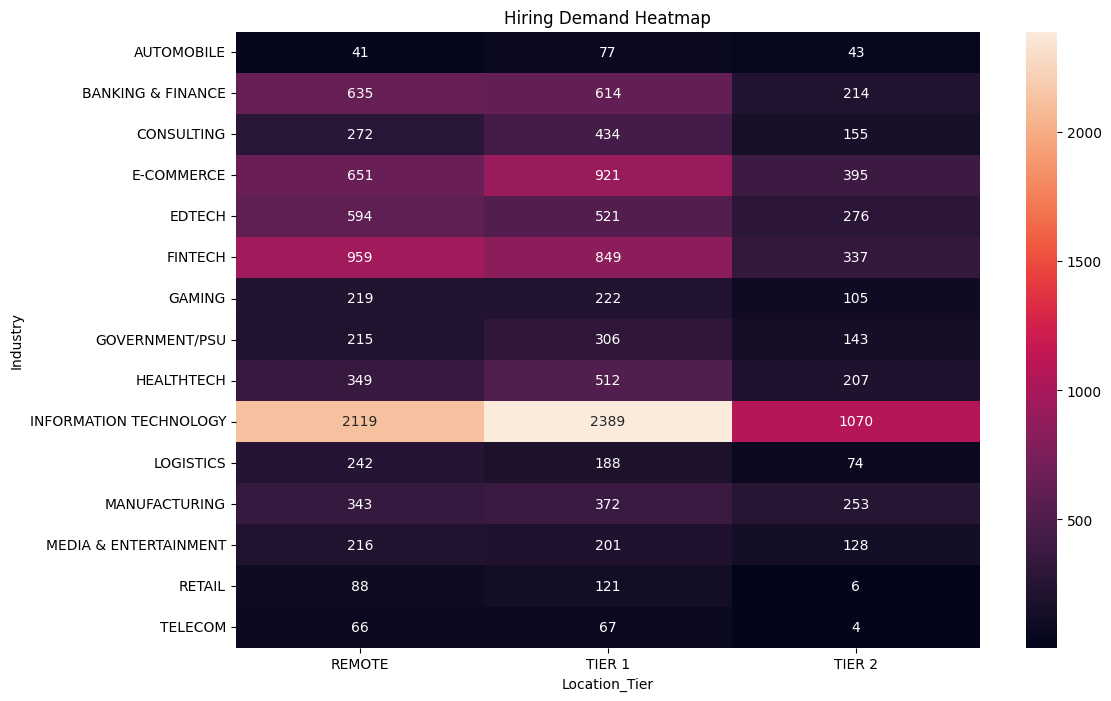

In [ ]:
# VISUALIZATION 3 - HIRING DEMAND HEATMAP
pivot_df = heatmap_pd.pivot(
    index="Industry",
    columns="Location_Tier",
    values="Total_Openings"
)
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".0f"
)

plt.title("Hiring Demand Heatmap")

plt.show()


In [25]:
plt.savefig("output/reports/hiring_heatmap.png")

<Figure size 640x480 with 0 Axes>

## USE CASE 2 — SALARY & SKILL INTELLIGENCE ENGINE

In [26]:
skills_df

DataFrame[Job_ID: string, Job_Title: string, Company: string, Company_Type: string, Industry: string, City: string, Location_Tier: string, Experience_Level: string, Job_Type: string, Work_Mode: string, Salary_LPA: double, Skills_Required: string, Education_Required: string, Openings: int, Applicants: int, Company_Rating: double, Date_Posted: date, Salary_Per_Applicant: double, Hiring_Demand_Index: double, Remote_Flag: int, High_Paying_Job_Flag: int, Salary_LPA_scaled: vector, Company_Type_indexed: double, Industry_indexed: double, City_indexed: double, Location_Tier_indexed: double, Experience_Level_indexed: double, Job_Type_indexed: double, Work_Mode_indexed: double, Education_Required_indexed: double, Skill_Count: int, Skill: string]

In [28]:
skills_df.select(
    "Company",
    "Skill",
    "Salary_LPA",
    "Experience_Level"
).show(20, truncate=False)

+-----------+-------------+----------+----------------+
|Company    |Skill        |Salary_LPA|Experience_Level|
+-----------+-------------+----------+----------------+
|Meesho     |REACT        |25.6      |MID (3-6 YRS)   |
|Meesho     |NEXT.JS      |25.6      |MID (3-6 YRS)   |
|Meesho     |HTML/CSS     |25.6      |MID (3-6 YRS)   |
|Meesho     |TYPESCRIPT   |25.6      |MID (3-6 YRS)   |
|Meesho     |REDUX        |25.6      |MID (3-6 YRS)   |
|Meesho     |JAVASCRIPT   |25.6      |MID (3-6 YRS)   |
|Groww      |PUBLICATIONS |84.8      |LEAD (10+ YRS)  |
|Groww      |NLP          |84.8      |LEAD (10+ YRS)  |
|Groww      |DEEP LEARNING|84.8      |LEAD (10+ YRS)  |
|Groww      |PYTORCH      |84.8      |LEAD (10+ YRS)  |
|Amazon     |LINUX        |18.0      |MID (3-6 YRS)   |
|Amazon     |GCP          |18.0      |MID (3-6 YRS)   |
|Amazon     |KUBERNETES   |18.0      |MID (3-6 YRS)   |
|Amazon     |TERRAFORM    |18.0      |MID (3-6 YRS)   |
|Amazon     |DOCKER       |18.0      |MID (3-6 Y

In [30]:
#COMPUTE AVERAGE SALARY BY SKILL
from pyspark.sql.functions import avg, count

skill_salary = skills_df.groupBy("Skill").agg(
    avg("Salary_LPA").alias("Average_Salary"),
    count("*").alias("Job_Count")
).orderBy(col("Average_Salary").desc())
skill_salary.show(20, truncate=False)

+------------------+------------------+---------+
|Skill             |Average_Salary    |Job_Count|
+------------------+------------------+---------+
|VECTOR DBS        |26.61224489795918 |98       |
|MACHINE LEARNING  |26.577083333333334|96       |
|PUBLICATIONS      |25.67659574468085 |47       |
|DEEP LEARNING     |25.609499999999993|200      |
|RAG               |25.582926829268295|82       |
|LANGCHAIN         |25.56625          |80       |
|OPENCV            |25.09038461538461 |52       |
|NLP               |25.06851063829787 |235      |
|OPENAI API        |24.60645161290323 |93       |
|SCIKIT-LEARN      |23.815183246073293|191      |
|PROMPT ENGINEERING|23.447727272727274|88       |
|MLFLOW            |23.176811594202903|69       |
|PANDAS            |23.014130434782604|92       |
|STATISTICS        |22.82886297376091 |343      |
|CSS               |22.38837209302326 |86       |
|WIREFRAMING       |22.38350515463917 |97       |
|OKRS              |22.075            |64       |


In [31]:
#FILTER LOW-FREQUENCY SKILLS
skill_salary_filtered = skill_salary.filter(
    col("Job_Count") >= 5
)
skill_salary_filtered.write.mode("overwrite").csv(
    "output/analytics/skill_salary",
    header=True
)

In [32]:
#EXPERIENCE-LEVEL SALARY ANALYSIS
experience_salary = df.groupBy(
    "Experience_Level"
).agg(
    avg("Salary_LPA").alias("Average_Salary"),
    count("*").alias("Job_Count")
).orderBy(col("Average_Salary").desc())
experience_salary.show(truncate=False)

+-----------------+------------------+---------+
|Experience_Level |Average_Salary    |Job_Count|
+-----------------+------------------+---------+
|LEAD (10+ YRS)   |52.95224171539955 |513      |
|SENIOR (6-10 YRS)|34.1884476534296  |831      |
|MID (3-6 YRS)    |18.496734397677773|1378     |
|JUNIOR (1-3 YRS) |9.920382165605107 |1256     |
|FRESHER (0-1 YR) |5.502544031311155 |1022     |
+-----------------+------------------+---------+



In [33]:
#WORK MODE SALARY ANALYSIS
workmode_salary = df.groupBy(
    "Work_Mode"
).agg(
    avg("Salary_LPA").alias("Average_Salary"),
    count("*").alias("Total_Jobs")
).orderBy(col("Average_Salary").desc())
workmode_salary.show(truncate=False)

+---------+------------------+----------+
|Work_Mode|Average_Salary    |Total_Jobs|
+---------+------------------+----------+
|ON-SITE  |20.080249376558626|2005      |
|REMOTE   |19.965509076558792|1267      |
|HYBRID   |19.438657407407387|1728      |
+---------+------------------+----------+



In [34]:
#CREATE SALARY BUCKETS (ADVANCED FEATURE ENGINEERING)
from pyspark.sql.functions import when

df = df.withColumn(
    "Salary_Category",
    when(col("Salary_LPA") < 10, "LOW")
    .when(col("Salary_LPA") < 20, "MEDIUM")
    .otherwise("HIGH")
)
df.select(
    "Salary_LPA",
    "Salary_Category"
).show(10)

+----------+---------------+
|Salary_LPA|Salary_Category|
+----------+---------------+
|      25.6|           HIGH|
|      84.8|           HIGH|
|      18.0|         MEDIUM|
|       7.5|            LOW|
|      20.3|           HIGH|
|       5.1|            LOW|
|      10.2|         MEDIUM|
|       6.1|            LOW|
|      13.9|         MEDIUM|
|      27.5|           HIGH|
+----------+---------------+
only showing top 10 rows


In [35]:
#SPARK SQL ANALYTICS
df.createOrReplaceTempView("jobs")
skills_df.createOrReplaceTempView("skills")

top_paying_industries = spark.sql("""
SELECT
    Industry,
    ROUND(AVG(Salary_LPA), 2) AS Avg_Salary,
    COUNT(*) AS Total_Jobs
FROM jobs
GROUP BY Industry
ORDER BY Avg_Salary DESC
""")

top_paying_industries.show(truncate=False)

+----------------------+----------+----------+
|Industry              |Avg_Salary|Total_Jobs|
+----------------------+----------+----------+
|LOGISTICS             |24.43     |123       |
|RETAIL                |22.28     |52        |
|BANKING & FINANCE     |20.85     |404       |
|MANUFACTURING         |20.7      |254       |
|TELECOM               |20.63     |38        |
|EDTECH                |20.47     |401       |
|INFORMATION TECHNOLOGY|20.4      |1545      |
|AUTOMOBILE            |19.31     |46        |
|E-COMMERCE            |19.27     |511       |
|GOVERNMENT/PSU        |19.27     |202       |
|FINTECH               |18.88     |543       |
|GAMING                |18.62     |146       |
|MEDIA & ENTERTAINMENT |18.55     |148       |
|CONSULTING            |18.47     |261       |
|HEALTHTECH            |17.29     |326       |
+----------------------+----------+----------+



In [36]:
#TOP PAYING SKILLS USING SQL
top_paying_skills_sql = spark.sql("""
SELECT
    Skill,
    ROUND(AVG(Salary_LPA), 2) AS Avg_Salary,
    COUNT(*) AS Job_Count
FROM skills
GROUP BY Skill
HAVING COUNT(*) >= 5
ORDER BY Avg_Salary DESC
""")

skill_salary_filtered.cache()
experience_salary.cache()
workmode_salary.cache()

DataFrame[Work_Mode: string, Average_Salary: double, Total_Jobs: bigint]

In [38]:
#Convert to Pandas for Visualization
skill_salary_pd = skill_salary_filtered.toPandas()

experience_salary_pd = experience_salary.toPandas()

workmode_salary_pd = workmode_salary.toPandas()

salary_distribution_pd = df.select(
    "Experience_Level",
    "Salary_LPA"
).toPandas()

workmode_distribution_pd = df.select(
    "Work_Mode",
    "Salary_LPA"
).toPandas()

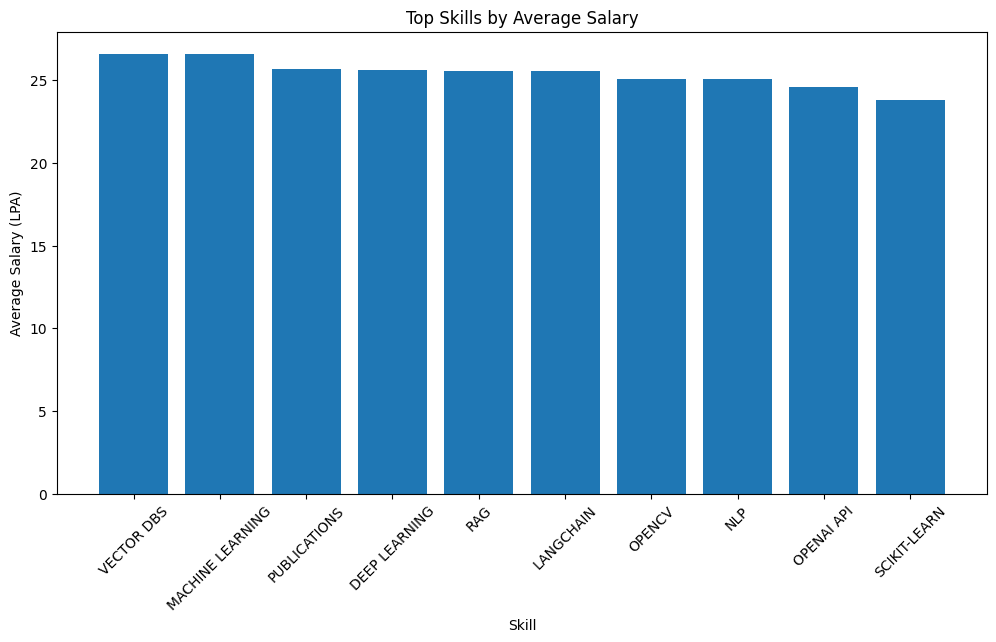

In [39]:
#VISUALIZATION 1 - TOP SKILLS BY AVERAGE SALARY
import matplotlib.pyplot as plt

top_skills = skill_salary_pd.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_skills["Skill"],
    top_skills["Average_Salary"]
)

plt.xticks(rotation=45)

plt.xlabel("Skill")
plt.ylabel("Average Salary (LPA)")
plt.title("Top Skills by Average Salary")

plt.show()

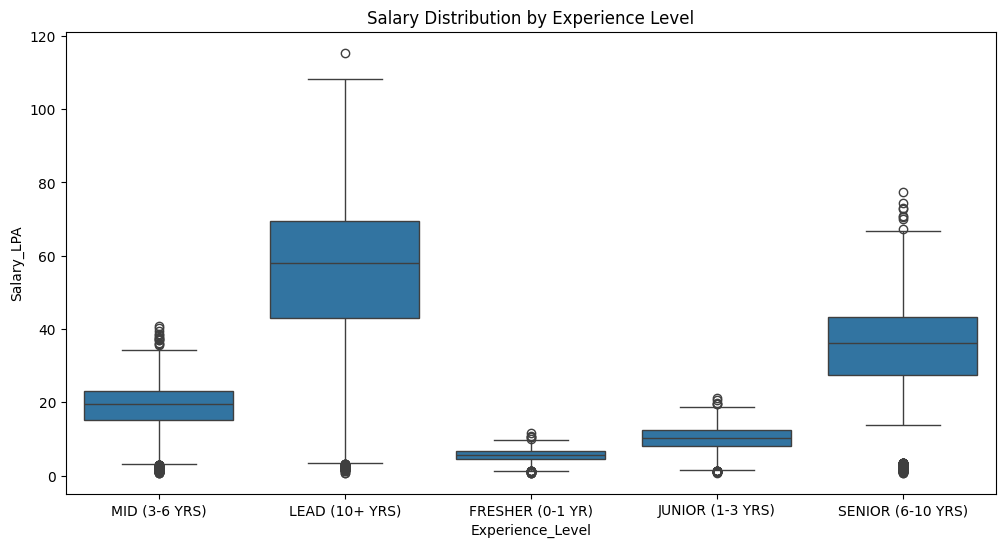

In [40]:
#VISUALIZATION 2 - SALARY DISTRIBUTION BY EXPERIENCE LEVEL
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Experience_Level",
    y="Salary_LPA",
    data=salary_distribution_pd
)

plt.title("Salary Distribution by Experience Level")

plt.show()

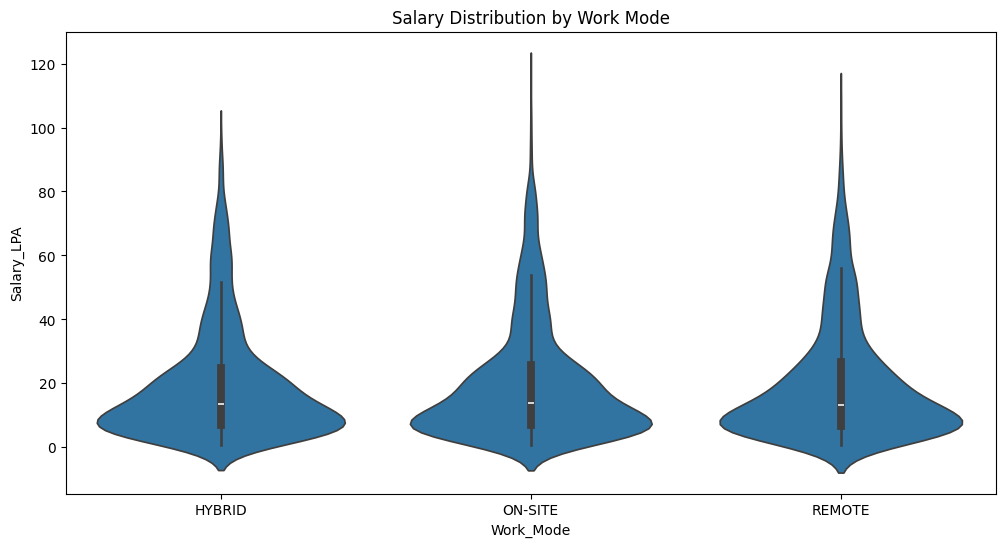

In [41]:
#VISUALIZATION 3 - REMOTE vs HYBRID vs ONSITE SALARY
plt.figure(figsize=(12,6))

sns.violinplot(
    x="Work_Mode",
    y="Salary_LPA",
    data=workmode_distribution_pd
)

plt.title("Salary Distribution by Work Mode")

plt.show()

In [42]:
plt.savefig(
    "output/reports/workmode_salary_distribution.png"
)

<Figure size 640x480 with 0 Axes>